In [1]:
import pickle
import pandas as pd
import numpy as np
from collections import Counter
from torchviz import make_dot

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from torch.nn import Linear, Sequential, ReLU, BatchNorm1d
from torch_geometric.nn import NNConv, global_add_pool, global_mean_pool
import torch.optim as optim
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [34]:
import random # to undersample trees
import matplotlib.pyplot as plt

In [4]:
with open('wolfGraphSU.pkl','rb') as q:
    dataq = pickle.load(q)
    SU_trees = dataq['SU_trees']
    wolfGraph = dataq['wolfGraph']
print("loaded!")

loaded!


In [5]:
# updated with new variables 
def tree_to_pyg(tree_graph, label):
    """ convert networkx tree to pyg data object ..with all new features"""

    # Node features: [ # elev, is_source, is_pit, 
    #                 max_vel, mean_vel, std_vel, mean_erosive, max_erosive, tidal_range,
    #                 total_inflow, mean_inflow, max_inflow]
    node_features = []
    node_mapping = {old_idx: new_idx for new_idx, old_idx in enumerate(tree_graph.nodes())}

    for node in tree_graph.nodes():
        feat = [
            tree_graph.nodes[node]['elev'],
            #1.0 if tree_graph.nodes[node].get('is_source',False) else 0.0, 
            #1.0 if tree_graph.nodes[node].get('is_source',False) else 0.0,
            tree_graph.nodes[node].get('max_vel', 0.0),
            tree_graph.nodes[node].get('mean_vel', 0.0),
            tree_graph.nodes[node].get('tidal_range', 0.0),
            tree_graph.nodes[node].get('std_vel', 0.0),
            tree_graph.nodes[node].get('mean_erosive_power', 0.0),
            tree_graph.nodes[node].get('max_erosive_power', 0.0),
            tree_graph.nodes[node].get('total_inflow', 0.0),
            tree_graph.nodes[node].get('mean_inflow', 0.0),
            tree_graph.nodes[node].get('max_inflow', 0.0)
        ]
        node_features.append(feat)

    x = torch.tensor(node_features, dtype=torch.float)

    # edge indices and weights
    edge_index = []
    edge_weight = []

    for u, v in tree_graph.edges():
        edge_index.append([node_mapping[u], node_mapping[v]])
        edge_weight.append(tree_graph.edges[u, v]['weight'])

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_weight, dtype=torch.float).view(-1,1)

    # label
    y = torch.tensor([label], dtype=torch.long)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

In [6]:
# attempt 3 : S + U rebuild dataset # hydro data only

label_map = {'S': 0, 'U': 1}  # Binary classification

# Rebuild dataset
pyg_dataset = []
for pit_idx, tree in SU_trees.items():
    stability = wolfGraph.nodes[pit_idx]['stability']
    label = label_map[stability]
    pyg_data = tree_to_pyg(tree, label)
    pyg_dataset.append(pyg_data)

In [7]:
# check label distribution (again!)
labels = [data.y.item() for data in pyg_dataset]
print("\nlabel distribution:")
for name, code in label_map.items():
    count = labels.count(code)
    print(f" {name} ({code}): {count}")


label distribution:
 S (0): 230
 U (1): 229


In [8]:
# 2. train/test split (80/20)
train_data, test_data = train_test_split(
    pyg_dataset,
    test_size = 0.2,
    random_state = 42,
    stratify=labels # keep class balance in both splits
)

print(f"train: {len(train_data)}, test: {len(test_data)}")

train: 367, test: 92


In [43]:
# 3. dataloaders
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

print(f"\nTrain: {len(train_loader)}, Test: {len(test_loader)}")


Train: 23, Test: 6


In [10]:
# quick batch check
for batch in train_loader:
    print(f"batch: {batch}")
    print(f"nodes: {batch.num_nodes}, edges: {batch.num_edges}")
    print(f"labels: {batch.y}")
    break
    

batch: DataBatch(x=[2204, 10], edge_index=[2, 2188], edge_attr=[2188, 1], y=[16], batch=[2204], ptr=[17])
nodes: 2204, edges: 2188
labels: tensor([0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1])


In [11]:
# Quick data check
print(f"Dataset size: {len(pyg_dataset)}")
print(f"Train size: {len(train_data)}")
print(f"Test size: {len(test_data)}")

# Check a sample
sample = pyg_dataset[0]
print(f"Sample features shape: {sample.x.shape}")
print(f"Sample has {sample.num_nodes} nodes")
print(f"Label: {sample.y.item()}")

Dataset size: 459
Train size: 367
Test size: 92
Sample features shape: torch.Size([402, 10])
Sample has 402 nodes
Label: 1


In [37]:
# check edge weights loading
sample = test_loader.dataset[0]
print(f"Has edge_attr: {hasattr(sample, 'edge_attr')}")
print(f"Edge_attr shape: {sample.edge_attr.shape if hasattr(sample, 'edge_attr') else 'None'}")

Has edge_attr: True
Edge_attr shape: torch.Size([56, 1])


In [13]:
# attempt 3(7!) with NNConv

class SlopeGNN(torch.nn.Module):
    def __init__(self, num_node_features, num_edge_features=1, hidden_dim=64, num_classes=2):
        super().__init__()

        # edge network - learns to use slope weights
        edge_nn1 = Sequential(
            nn.Linear(num_edge_features, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_node_features*hidden_dim)
        )

        self.conv1 = NNConv(num_node_features, hidden_dim, edge_nn1, aggr='mean')

        edge_nn2 = nn.Sequential(
            nn.Linear(num_edge_features, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim*hidden_dim)
        )

        self.conv2 = NNConv(hidden_dim, hidden_dim, edge_nn2, aggr='mean')

        self.fc1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc2 = nn.Linear(hidden_dim // 2, num_classes)

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch

        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.dropout(x, p=0.2, training=self.training)

        x = F.relu(self.conv2(x, edge_index, edge_attr))

        x = global_mean_pool(x, batch)

        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.fc2(x)

        return F.log_softmax(x, dim=1)

In [14]:
# setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [29]:
# initialize mddel
# reinitialize model every time
num_features = 10# set to chosen number of features
model = SlopeGNN(num_node_features=num_features, hidden_dim=64, num_classes=2).to(device) # 4->3->2 classes!

In [30]:
print(model)
print(f"total parameters: {sum(p.numel() for p in model.parameters())}")

SlopeGNN(
  (conv1): NNConv(10, 64, aggr=mean, nn=Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=640, bias=True)
  ))
  (conv2): NNConv(64, 64, aggr=mean, nn=Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=4096, bias=True)
  ))
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=2, bias=True)
)
total parameters: 315106


In [31]:
# criterion = torch.nn.NLLLoss() # neg. log-likelihood (pairs w. log_softmax)
# opt: use weighted loss
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.NLLLoss()
print(f"Criterion using weights: {criterion.weight is not None}")

Criterion using weights: False


In [20]:
# training function
def train(loader):
    model.train()
    total_loss = 0
    correct = 0

    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()

        out = model(data)
        loss = criterion(out, data.y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.num_graphs
        pred = out.argmax(dim=1)
        correct += (pred == data.y).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)

In [21]:
# testing function
def test(loader):
    model.eval()
    correct = 0

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            pred = out.argmax(dim=1)
            correct += (pred == data.y).sum().item()

    return correct / len(loader.dataset)

In [46]:
# training loop w/ early stopping

best_test_acc = 0
best_model = None
checkpoint = None
patience = 30
no_improve_count = 0
max_epochs = 300
train_losses = []
train_accs = []
test_accs = []

for epoch in range(max_epochs):
    train_loss, train_acc = train(train_loader)
    test_acc = test(test_loader)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if epoch % 10 == 0:
        print(f'epoch {epoch:03d}, loss: {train_loss:.4f}, train acc: {train_acc:.4f}, test acc: {test_acc:.4f}')

    if test_acc > best_test_acc + 0.001:
        best_test_acc = test_acc
        no_improve_count = 0
        best_model = model.state_dict().copy()
        best_epoch = epoch
        print(f"✓ Epoch {epoch}: New best: {test_acc:.4f} Train: {train_acc:.4}")
    else:
        no_improve_count += 1

    if no_improve_count >= patience:
        print(f"early stopping at epoch {epoch}")
        print(f"Best was epoch {best_epoch} with {best_test_acc:.4f}")
        print(f"final test accuracy: {test_accs[-1]:.4f}")
        if best_model is not None:
            model.load_state_dict(best_model)  # ← LOAD BEST MODEL
            #optimizer.load_state_dict(['optimizer'])
            print(f"Loaded model from epoch {best_epoch}")
        break
    

epoch 000, loss: 0.4802, train acc: 0.7711, test acc: 0.6087
✓ Epoch 0: New best: 0.6087 Train: 0.7711
✓ Epoch 1: New best: 0.6196 Train: 0.7711
✓ Epoch 6: New best: 0.6739 Train: 0.7302
epoch 010, loss: 0.4449, train acc: 0.7875, test acc: 0.5870
epoch 020, loss: 0.4950, train acc: 0.6975, test acc: 0.5761
epoch 030, loss: 0.3977, train acc: 0.7984, test acc: 0.6413
early stopping at epoch 36
Best was epoch 6 with 0.6739
final test accuracy: 0.6304
Loaded model from epoch 6


# training loop
num_epochs = 300
train_losses = []
train_accs = []
test_accs = []

print(f"starting training ...\n")

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train(train_loader)
    test_acc = test(test_loader)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if epoch % 10 == 0:
        print(f'epoch {epoch:03d}, loss: {train_loss:.4f}, train acc: {train_acc:.4f}, test acc: {test_acc:.4f}')

print("\ntraining complete!")
print(f"final test accuracy: {test_accs[-1]:.4f}")

In [41]:
model.load_state_dict(best_model)
print(f"Loaded best model. Now testing...")
model.eval()
test_acc_verify = test(test_loader)  # Does this match best_test_acc?
print(f"Best saved: {best_test_acc:.4f}, Re-tested: {test_acc_verify:.4f}")

Loaded best model. Now testing...
Best saved: 0.6957, Re-tested: 0.5870


In [20]:
# results 
# using 10 features and 64 hidden layers
# early stopping patience 30, max epochs 300

# run 1: stopped at 94 epochs
# Stable: 78.3% (36/46)
# Unstable: 69.6% (32/46)

# results_stable = [78.3, ]
# results_unstable = [69.6, ]

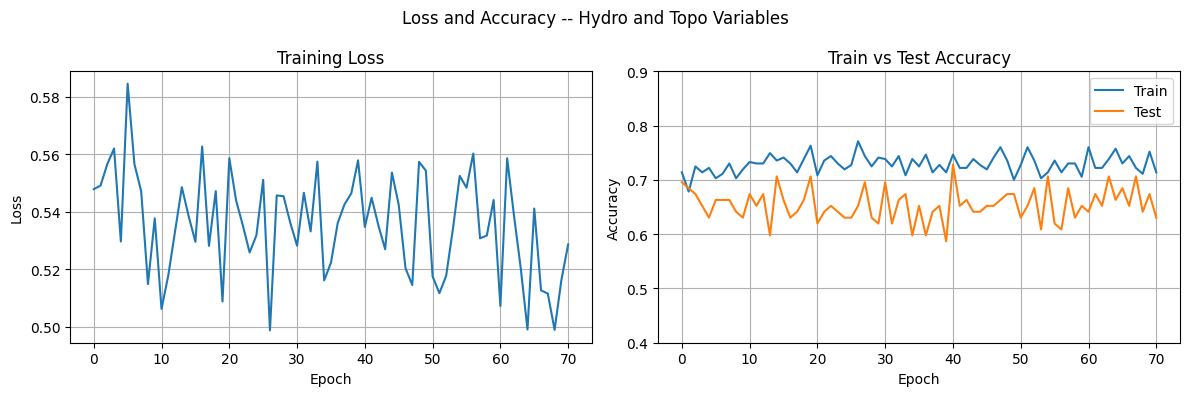

In [29]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
ax1.plot(train_losses)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
#ax1.set_ylim(0.4, 1.25)
ax1.grid(True)

# Accuracy curves
ax2.plot(train_accs, label='Train')
ax2.plot(test_accs, label='Test')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Train vs Test Accuracy')
ax2.legend()
ax2.set_ylim(0.4, 0.9)
ax2.grid(True)

fig.suptitle("Loss and Accuracy -- Hydro and Topo Variables")
plt.tight_layout()
#plt.savefig("fig_459hydroTopoSU69_loss.png")
plt.show()

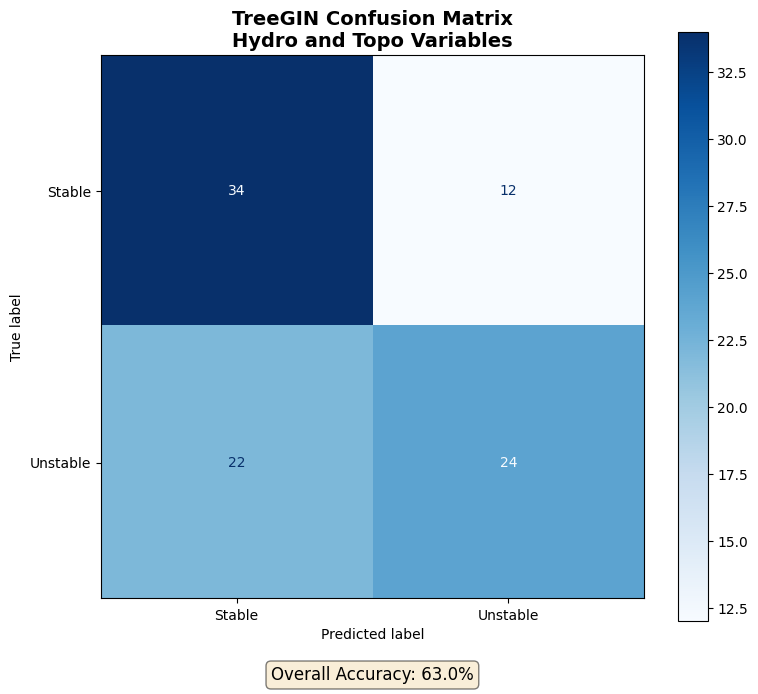


=== Per-Class Performance ===
Stable: 73.9% (34/46)
Unstable: 52.2% (24/46)


In [47]:
# Get predictions on test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        out = model(data)
        pred = out.argmax(dim=1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(data.y.cpu().numpy())

# Create confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Stable', 'Unstable'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('TreeGIN Confusion Matrix\nHydro and Topo Variables', fontsize=14, fontweight='bold')

# Add accuracy to plot
acc = np.trace(cm) / np.sum(cm)
ax.text(0.5, -0.15, f'Overall Accuracy: {acc:.1%}', 
        transform=ax.transAxes, ha='center', fontsize=12,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
#plt.savefig('fig_459hydroTopoSU69_confM.png', dpi=300, bbox_inches='tight')
plt.show()

# Print per-class accuracy
print("\n=== Per-Class Performance ===")
for i, label in enumerate(['Stable', 'Unstable']):
    class_acc = cm[i, i] / cm[i, :].sum() if cm[i, :].sum() > 0 else 0
    print(f"{label}: {class_acc:.1%} ({cm[i, i]}/{cm[i, :].sum()})")

In [49]:
# script to debug early stopping

# After loading best model
model.load_state_dict(best_model)
model.eval()

# Method 1: Using test() function
test_acc_1 = test(test_loader)
print(f"Method 1 (test function): {test_acc_1:.4f}")

# Method 2: Manual calculation
all_preds = []
all_labels = []
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        out = model(data)
        pred = out.argmax(dim=1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(data.y.cpu().numpy())

manual_acc = (np.array(all_preds) == np.array(all_labels)).mean()
print(f"Method 2 (manual): {manual_acc:.4f}")

# Method 3: From confusion matrix
cm = confusion_matrix(all_labels, all_preds)
cm_acc = np.trace(cm) / np.sum(cm)
print(f"Method 3 (confusion matrix): {cm_acc:.4f}")

print(f"\nThey should all match!")

Method 1 (test function): 0.6304
Method 2 (manual): 0.6304
Method 3 (confusion matrix): 0.6304

They should all match!
